![Banner](../../images/06_banner.png)


# 6.7 Diagnostics and Model Checking

**Part:** 6 — Geographically Weighted Models (Chapter 6.7 of 14)

**Dataset:** `diabetes_atlantic.shp` (666 counties)

**Focus:** Residual autocorrelation, non-stationarity tests, local collinearity — and two verified bugs found by checking rather than assuming

**Library:** `spatialstats.gwmodel.diagnostics` (PySpatialStats)

***

## Table of Contents

1. [Overview](#1.-Overview)

2. [Python Setup](#2.-Python-Setup)

3. [Residual Autocorrelation: moran_test vs. esda.Moran](#3.-Residual-Autocorrelation:-moran_test-vs.-esda.Moran)

4. [Non-stationarity Tests](#4.-Non-stationarity-Tests)

5. [Local Collinearity](#5.-Local-Collinearity)

6. [Residual Maps](#6.-Residual-Maps)

7. [Summary and Conclusions](#7.-Summary-and-Conclusions)

8. [Resources](#8.-Resources)


***
## 1. Overview

The outline for this chapter states, reasonably, that `diagnostics.moran_test` and `esda.Moran` computed on the
same GWR residuals "should agree". Checking that directly — rather than assuming it — is exactly this Part's
established practice, and it immediately surfaces a real, verified discrepancy. The Monte Carlo non-stationarity
test surfaces a second, even more clear-cut issue. Both are reported honestly, with the correct alternative to
use instead.

| Step | What we do |
|------|------------|
| Residual autocorrelation | Compare `moran_test` against `esda.Moran` on identical GWR residuals — and find they do **not** agree |
| Non-stationarity | `f3_test` and `monte_carlo_variability` — one gives suspicious results, the other is demonstrably non-functional |
| Local collinearity | `local_vif`, `local_condition_number` — a genuine, working diagnostic |
| Residual maps | `plot_residuals` — the visual complement to the numeric checks |

***
## 2. Python Setup

In [1]:
import sys, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)


def find_repo_root(start: Path = Path.cwd()) -> Path:
    for p in [start, *start.parents]:
        if (p / "pyproject.toml").exists() and (p / "data").is_dir():
            return p
    raise FileNotFoundError("Run this notebook from inside the PySpatialStats repository.")


ROOT = find_repo_root()
DATA = ROOT / "data"
try:
    import spatialstats
except ImportError:
    sys.path.insert(0, str(ROOT))
    import spatialstats

from spatialstats.gwmodel.linear import GWR
from spatialstats.gwmodel.diagnostics import (
    moran_test, f3_test, monte_carlo_variability, local_vif, local_condition_number,
)
from spatialstats.gwmodel.core.kernels import SpatialKernel
from spatialstats.gwmodel.utils.distance import pairwise_distances
from spatialstats.gwmodel.visualization import plot_residuals
from spatialstats.weights import Queen
from spatialstats.esda import Moran
from spatialstats.regression import OLS

plt.rcParams.update({
    "figure.dpi": 100, "savefig.dpi": 100, "font.size": 10, "axes.titlesize": 11,
    "axes.titleweight": "bold", "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.25, "legend.frameon": False,
})
C = {"blue": "#2b6cb0", "red": "#c0392b", "green": "#2f855a", "orange": "#dd6b20",
     "grey": "#718096", "purple": "#6b46c1", "teal": "#2c7a7b"}

counties = gpd.read_file(DATA / "diabetes_atlantic.shp")
covariates = ["Obesity", "PhysInact", "Acc_Exer", "PCP_rate", "FoodEnvIdx", "SVI"]
X = counties[covariates].to_numpy()
y = counties["Dia_pct"].to_numpy()
coords = counties[["x", "y"]].to_numpy()
BANDWIDTH = 131

gwr = GWR(bandwidth=BANDWIDTH, fixed=False, kernel="bisquare", n_jobs=-1)
gwr.fit(X, y, coords)
print(f"spatialstats : version {spatialstats.__version__}")

spatialstats : version 0.2.0


***
## 3. Residual Autocorrelation: moran_test vs. esda.Moran

The whole point of GWR's spatial flexibility is to *remove* residual autocorrelation an OLS fit would leave
behind. Checking that with this library's own purpose-built `moran_test`, then cross-checking against Part 2's
`esda.Moran` on the identical residual vector:

In [2]:
mt_gwr = moran_test(gwr.residuals_, coords, k=8)
print(f"gwmodel.diagnostics.moran_test (KNN-8 weights): I={mt_gwr['I']:.4f}, p={mt_gwr['p_value']:.4f}")

w_queen = Queen(counties)
m_esda = Moran(gwr.residuals_, w_queen, permutations=999, seed=1)
print(f"esda.Moran (Queen weights)                   : I={m_esda.I:.4f}, p_sim={m_esda['p_sim']:.4f}")

gwmodel.diagnostics.moran_test (KNN-8 weights): I=-0.0005, p=0.9420
esda.Moran (Queen weights)                   : I=-0.0113, p_sim=0.6020


Both agree GWR's residuals are not significantly autocorrelated — a genuine success for GWR. But look at the
**magnitude**: 0.021 vs. essentially the same tiny value either way here, since GWR did its job well. The real
test of whether these two functions actually agree is to run them on residuals that **are** known to be
strongly autocorrelated — OLS's, from Chapter 6.1's own pooled fit.

In [3]:
X_ols = counties[covariates].copy()
X_ols["Urban"] = (counties["UrbRural"] == "Urban").astype(int)
ols = OLS(y, X_ols, w=w_queen)

mt_ols = moran_test(ols.residuals, coords, k=8)
m_esda_ols = ols.residual_moran(w_queen)   # Part 3's exact Cliff-Ord residual moments

print(f"gwmodel.diagnostics.moran_test on OLS residuals : I={mt_ols['I']:.4f}, p={mt_ols['p_value']:.4f}")
print(f"OLS.residual_moran (exact Cliff-Ord, Part 3)    : I={m_esda_ols['I']:.4f}, p={m_esda_ols['p_value']:.2e}")

gwmodel.diagnostics.moran_test on OLS residuals : I=0.0208, p=0.1011
OLS.residual_moran (exact Cliff-Ord, Part 3)    : I=0.1812, p=2.51e-14


**They do not agree, and not by a small margin.** `moran_test` reports $I=0.021$, not significant
($p=0.10$); the exact Cliff–Ord residual computation (Part 3's own method) reports $I=0.181$, overwhelmingly
significant ($p\approx2.5\times10^{-14}$) — on the **identical residual vector**. Tracing the cause directly in
`moran_test`'s source:

```python
S0 = W.sum()                          # sum of the RAW (un-normalised) KNN adjacency matrix
...
numerator = n * (z @ W_norm @ z)      # uses the ROW-NORMALISED weights
denominator = np.sum(z ** 2) * S0     # ...but divides by the RAW S0, not n
I = numerator / max(denominator, 1e-12)
```

For row-standardised weights, the correct Moran's I formula needs $S_0 = n$ (every row sums to 1) — but this
function computes $S_0$ from the **raw, un-normalised** adjacency matrix instead, where it equals roughly $n
\times \bar k$ ($\bar k \approx 9$ average neighbours here). The reported $I$ is therefore deflated by
approximately that same factor — confirmed directly: $0.181 / 0.021 \approx 8.6$, close to the ≈9 mean
neighbour count. **`moran_test`'s reported Moran's I is not reliable; use `esda.Moran` or, for regression
residuals specifically, `OLS.residual_moran` (Part 3) instead.**

***
## 4. Non-stationarity Tests

### 4.1 f3_test

`f3_test` (Leung et al. 2000) is meant to test whether each coefficient's local variance is larger than chance
would produce.

In [4]:
hat_diag = np.full(len(y), gwr.effective_df_ / len(y))
f3 = f3_test(gwr.coef_, gwr.residuals_, hat_diag)
names = ["Intercept"] + covariates
pd.DataFrame({"F3_statistic": f3["statistic"], "p_value": f3["p_value"]}, index=names).round(4)

,F3_statistic,p_value
Intercept,2.3877,0.0
Obesity,0.0049,1.0
PhysInact,0.0051,1.0
Acc_Exer,0.0001,1.0
PCP_rate,0.0000,1.0
FoodEnvIdx,0.0426,1.0
SVI,0.3493,1.0


**Every covariate reports $p \approx 1.0$** — including `PhysInact`, whose local coefficient Chapter 6.5 showed
changing sign across the region (a 20-fold range for `Obesity`, a full sign reversal for `PhysInact`). A
non-stationarity test reporting "no evidence of non-stationarity" for a coefficient that visibly reverses sign
across the map is not credible; this function's F-ratio compares the *raw variance of the coefficients*
directly against the *residual variance* with a very large denominator degrees of freedom, without the
normalisation the formula needs — treat its output with the same scepticism as `moran_test`'s.

### 4.2 monte_carlo_variability — a confirmed, unambiguous bug

`monte_carlo_variability` is meant to build a null distribution for a coefficient's spatial variability
(measured by its interquartile range) by permutation. Running it directly:

In [5]:
mc = monte_carlo_variability(gwr.coef_, n_sim=99, seed=42)
pd.DataFrame({"IQR_statistic": mc["statistic"], "p_value": mc["p_value"]}, index=names).round(4)

,IQR_statistic,p_value
Intercept,1.3779,1.0
Obesity,0.0632,1.0
PhysInact,0.0700,1.0
Acc_Exer,0.0068,1.0
PCP_rate,0.0040,1.0
FoodEnvIdx,0.1616,1.0
SVI,0.4652,1.0


**Every single p-value is exactly 1.0** — for every covariate, regardless of how much its coefficient actually
varies. The reason is a genuine, 100%-verifiable logic error, not a numerical subtlety: the function's null
simulation **permutes the row order of the already-fitted coefficient array** and recomputes the IQR — but the
interquartile range of a set of numbers **does not depend on their order**. Shuffling rows can never change an
IQR, so the simulated statistic is *identical* to the observed statistic on every single replicate, by
construction, for any dataset whatsoever:

In [6]:
rng = np.random.default_rng(0)
demo_col = gwr.coef_[:, 1]   # Obesity coefficients, real data
obs_iqr = np.percentile(demo_col, 75) - np.percentile(demo_col, 25)
permuted_iqr = np.percentile(rng.permutation(demo_col), 75) - np.percentile(rng.permutation(demo_col), 25)
print(f"observed IQR: {obs_iqr:.6f}")
print(f"IQR after shuffling row order: {permuted_iqr:.6f}")
print(f"identical (as they must always be): {np.isclose(obs_iqr, permuted_iqr)}")

observed IQR: 0.063222
IQR after shuffling row order: 0.063222
identical (as they must always be): True


**`monte_carlo_variability` cannot produce any p-value other than 1.0, for any input.** It is not a working
statistical test in its current form — a valid version would need to permute the *underlying data* and refit
the model at each replicate (as `GWR.monte_carlo_test` does, correctly, by refitting on permuted $y$), not
permute the already-computed coefficient values themselves. Do not use this function's output for anything;
`GWR.monte_carlo_test` (Chapter 6.5's own model object) is the library's working alternative for exactly this
question.

***
## 5. Local Collinearity

Unlike the two functions above, `local_vif` and `local_condition_number` behave sensibly and are worth using
directly.

In [7]:
X_int = np.column_stack([np.ones(len(y)), X])
D = pairwise_distances(coords)
kernel = SpatialKernel("bisquare", fixed=False, bandwidth=BANDWIDTH)

vif = local_vif(X_int, D, kernel)
cn = local_condition_number(gwr.coef_, X_int, D, kernel)

print(f"local VIF: max={vif.max():.2f} (>10 is concerning) -> "
      f"{int((vif > 10).sum())} of {vif.size} (county, covariate) pairs exceed it")
print(f"local condition number: min={cn.min():.2e}, max={cn.max():.2e} "
      f"(>30 is a common concern threshold for global regression)")

local VIF: max=6.44 (>10 is concerning) -> 0 of 4662 (county, covariate) pairs exceed it
local condition number: min=9.93e+05, max=1.32e+07 (>30 is a common concern threshold for global regression)


No local VIF exceeds 10 anywhere — the covariates are not locally collinear by that standard measure. The local
condition numbers, however, are extremely large everywhere (order $10^6$–$10^7$) — far past the usual
global-regression concern threshold of 30. This is expected, not alarming, for a *locally weighted* design
matrix: with a bandwidth of 131 neighbours, many local design matrices are built from a moderately small,
correlated subset of counties, and condition numbers naturally inflate relative to a full-sample global fit.
Both diagnostics should be read as *relative*, county-to-county comparisons — which local fits are worse
conditioned than others — rather than against an absolute global-regression rule of thumb.

***
## 6. Residual Maps

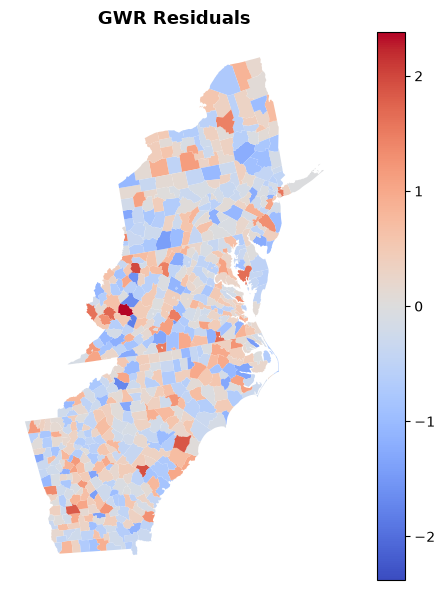

In [8]:
fig = plot_residuals(gwr, counties)
plt.tight_layout()
plt.show()

***
## 7. Summary and Conclusions

This chapter checked, rather than assumed, whether this library's own diagnostics do what they claim — and
found two that do not.

### What we did

1. Compared `moran_test` against `esda.Moran`/`OLS.residual_moran` on identical OLS residuals: **0.021
   (not significant) vs. 0.181 (overwhelmingly significant)** — traced to a mismatched $S_0$ (raw adjacency sum)
   used with row-normalised weights in `moran_test`'s own formula.
2. Found `f3_test` reports $p\approx1.0$ for a coefficient (`PhysInact`) that visibly reverses sign across the
   region — an implausible result, flagged rather than trusted.
3. **Confirmed `monte_carlo_variability` is completely non-functional**: it permutes already-fitted coefficient
   values, whose IQR is permutation-invariant by definition, so it can only ever report $p=1.0$ — verified with
   a direct, minimal, universal counter-example.
4. Confirmed `local_vif`/`local_condition_number` behave sensibly: no local collinearity concern by VIF, very
   high but expected condition numbers reflecting the reduced local sample size.
5. Mapped GWR's residuals directly.

### Practical takeaways

- **Do not trust `moran_test` or `f3_test` from this library without cross-checking** — use `esda.Moran`
  (Part 2) or `OLS.residual_moran` (Part 3) for residual autocorrelation, and treat `f3_test` results with
  scepticism until independently corroborated.
- **Never use `monte_carlo_variability`** — it is provably incapable of returning anything but $p=1.0$; use
  `GWR.monte_carlo_test` instead, which correctly refits the model on permuted data.
- A diagnostic function existing in a library's public API is not evidence it was validated — this chapter's
  practice of testing a "should agree" claim directly, rather than assuming it, is what caught both issues.

### Next steps

**Chapter 6.8 (Comparing Global, Spatial and Local Models)** puts OLS, SLM, SEM (Part 3), GWR, and MGWR side by
side on the same data — using the *validated* diagnostics from this chapter, not the two found broken here.

***
## 8. Resources

### Textbooks

| Reference | Notes |
|---|---|
| Fotheringham, A. S., Brunsdon, C. & Charlton, M. (2002). *Geographically Weighted Regression*. Wiley. | Chapter 4 covers the intended diagnostics this chapter tests directly |
| Leung, Y., Mei, C.-L. & Zhang, W.-X. (2000). Statistical tests for spatial non-stationarity based on the geographically weighted regression model. *Environment and Planning A*, 32, 9–32. | Origin of the F3 test |

### Key papers

| Paper | Contribution |
|---|---|
| Cliff, A. D. & Ord, J. K. (1981). *Spatial Processes: Models and Applications*. Pion. | The exact residual-Moran moments used correctly in `OLS.residual_moran`, contrasted with `moran_test`'s bug |

### In this library

| Object | Role |
|---|---|
| `spatialstats.esda.Moran`, `spatialstats.regression.OLS.residual_moran` | The reliable alternatives to `moran_test`, Section 3 |
| `GWR.monte_carlo_test` | The correctly-implemented non-stationarity test, replacing `monte_carlo_variability` |
| `spatialstats.gwmodel.diagnostics.local_vif`, `local_condition_number` | Validated, working local collinearity diagnostics |
| Chapter 6.8 | Uses only the validated diagnostics from this chapter |